In [1]:
import glob
import os
import librosa
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler

# Path to the metadata file
metadata_file_path = r'D:\download\Compressed\DF-keys-full\keys\DF\CM\trial_metadata.txt'

# Dictionary to hold file identifiers and labels
labels = {}
with open(metadata_file_path, 'r') as f:
    for line in f:
        parts = line.strip().split()
        file_identifier = parts[1]
        label = parts[5]
        labels[file_identifier] = label

# Directory containing the undersampled audio files
undersampled_audio_dir = r'D:\audio_files\undersampled_audio'
audio_files = glob.glob(os.path.join(undersampled_audio_dir, '*.flac'))

valid_audio_files = []
valid_labels = []

for audio_file in audio_files:
    file_name = os.path.basename(audio_file)
    file_identifier = file_name.split('.')[0]
    if file_identifier in labels:
        valid_audio_files.append(audio_file)
        valid_labels.append(labels[file_identifier])

print(f"Found {len(valid_audio_files)} audio files with corresponding labels.")

# Audio to MFCC conversion function
def audio_to_mfcc(audio_file, sr=22050, n_mfcc=13):
    audio, sample_rate = librosa.load(audio_file, sr=sr)
    mfcc = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=n_mfcc)
    return mfcc

def pad_or_truncate(mfcc, max_time_steps=400):
    if mfcc.shape[1] > max_time_steps:
        return mfcc[:, :max_time_steps]
    elif mfcc.shape[1] < max_time_steps:
        padding = max_time_steps - mfcc.shape[1]
        return np.pad(mfcc, ((0, 0), (0, padding)), mode='constant')
    return mfcc

# Preprocessing function with normalization
def preprocess_audio_files_rnn(audio_files, labels, n_mfcc=13, max_time_steps=400):
    mfcc_data = []
    label_data = []
    scaler = StandardScaler()
    
    for audio_file, label in zip(audio_files, labels):
        mfcc = audio_to_mfcc(audio_file, n_mfcc=n_mfcc)
        mfcc = pad_or_truncate(mfcc, max_time_steps=max_time_steps).T
        mfcc = scaler.fit_transform(mfcc)
        mfcc_data.append(mfcc)
        label_data.append(1 if label == 'spoof' else 0)

    return np.array(mfcc_data), np.array(label_data)

X, y = preprocess_audio_files_rnn(valid_audio_files, valid_labels)
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

def stratified_split_70_30(X, y, test_size=0.2, random_state=42):
    strat_split = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    for train_idx, test_idx in strat_split.split(X, y):
        X_train, y_train = X[train_idx], y[train_idx]
        X_test, y_test = X[test_idx], y[test_idx]
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = stratified_split_70_30(X, y)
print(f"Training set distribution: {np.bincount(y_train)}")
print(f"Test set distribution: {np.bincount(y_test)}")

def build_rnn_model(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        LSTM(128, return_sequences=True, activation='tanh'),
        Dropout(0.3),
        BatchNormalization(),
        LSTM(64, return_sequences=True, activation='tanh'),
        Dropout(0.3),
        BatchNormalization(),
        LSTM(32, activation='tanh'),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    return model

input_shape = (X_train.shape[1], X_train.shape[2])
rnn_model = build_rnn_model(input_shape)
rnn_model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = rnn_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)

test_loss, test_accuracy = rnn_model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

y_pred = (rnn_model.predict(X_test) > 0.5).astype(int).flatten()
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)


Found 45234 audio files with corresponding labels.
Shape of X: (45234, 400, 13)
Shape of y: (45234,)
Training set distribution: [18093 18094]
Test set distribution: [4524 4523]
Epoch 1/50
453/453 [==============================] - 47s 84ms/step - loss: 0.5666 - accuracy: 0.7213 - val_loss: 0.4953 - val_accuracy: 0.7727
Epoch 2/50
453/453 [==============================] - 41s 91ms/step - loss: 0.5125 - accuracy: 0.7610 - val_loss: 0.4803 - val_accuracy: 0.7749
Epoch 3/50
453/453 [==============================] - 41s 91ms/step - loss: 0.4876 - accuracy: 0.7761 - val_loss: 0.4490 - val_accuracy: 0.7900
Epoch 4/50
453/453 [==============================] - 42s 93ms/step - loss: 0.4711 - accuracy: 0.7831 - val_loss: 0.4479 - val_accuracy: 0.7899
Epoch 5/50
453/453 [==============================] - 45s 98ms/step - loss: 0.4575 - accuracy: 0.7893 - val_loss: 0.4299 - val_accuracy: 0.8022
Epoch 6/50
453/453 [==============================] - 50s 110ms/step - loss: 0.4472 - accuracy: 0.7921 

Here


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru (GRU)                   (None, 400, 128)          54912     
                                                                 
 dropout_4 (Dropout)         (None, 400, 128)          0         
                                                                 
 batch_normalization_2 (Batc  (None, 400, 128)         512       
 hNormalization)                                                 
                                                                 
 gru_1 (GRU)                 (None, 400, 64)           37248     
                                                                 
 dropout_5 (Dropout)         (None, 400, 64)           0         
                                                                 
 batch_normalization_3 (Batc  (None, 400, 64)          256       
 hNormalization)                                      

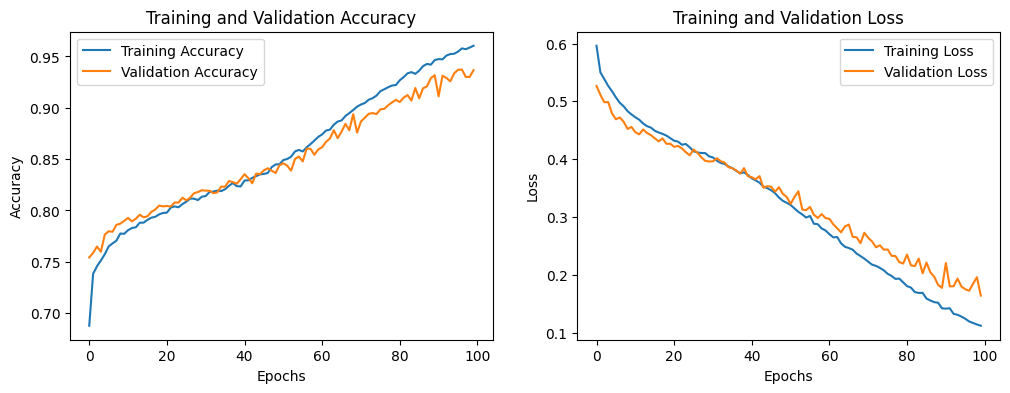

In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Input, GRU
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.optimizers import Adam
import numpy as np
import matplotlib.pyplot as plt


# Build RNN model
def build_rnn2_model(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        GRU(128, return_sequences=True, activation='tanh'),
        Dropout(0.3),
        BatchNormalization(),
        GRU(64, return_sequences=True, activation='tanh'),
        Dropout(0.3),
        BatchNormalization(),
        GRU(32, activation='tanh'),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    return model

# Define input shape
input_shape = (X_train.shape[1], X_train.shape[2])
rnn2_model = build_rnn2_model(input_shape)

# Compile the model
rnn2_model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

# **Add model summary here**
rnn2_model.summary()

# Early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = rnn2_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)

# Evaluate the model on the test set
test_loss, test_accuracy = rnn2_model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Predictions and classification report
y_pred = (rnn2_model.predict(X_test) > 0.5).astype(int).flatten()
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)

# Plot training & validation accuracy and loss
plt.figure(figsize=(12, 4))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru_3 (GRU)                 (None, 400, 128)          54912     
                                                                 
 dropout_8 (Dropout)         (None, 400, 128)          0         
                                                                 
 batch_normalization_4 (Batc  (None, 400, 128)         512       
 hNormalization)                                                 
                                                                 
 gru_4 (GRU)                 (None, 400, 64)           37248     
                                                                 
 dropout_9 (Dropout)         (None, 400, 64)           0         
                                                                 
 batch_normalization_5 (Batc  (None, 400, 64)          256       
 hNormalization)                                      

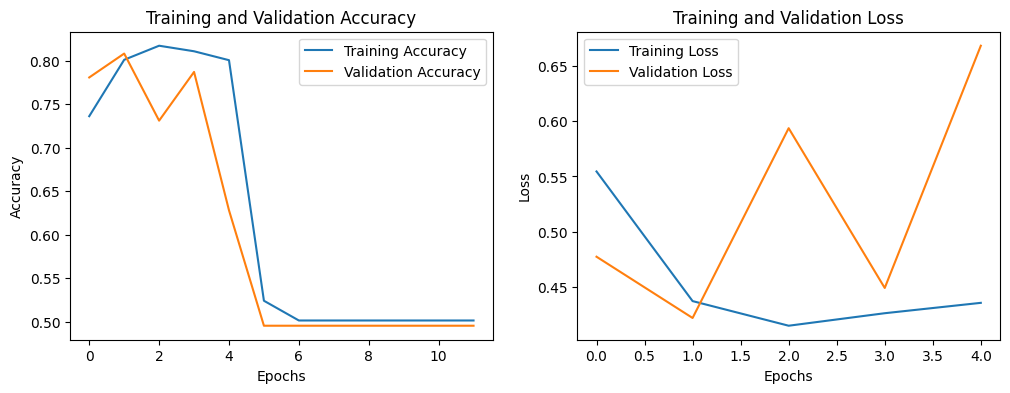

In [3]:
# Build RNN model
def build_rnn3_model(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        GRU(128, return_sequences=True, activation='tanh'),
        Dropout(0.3),
        BatchNormalization(),
        GRU(64, return_sequences=True, activation='tanh'),
        Dropout(0.3),
        BatchNormalization(),
        GRU(32, activation='tanh'),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    return model

# Define input shape
input_shape = (X_train.shape[1], X_train.shape[2])
rnn3_model = build_rnn3_model(input_shape)

# Compile the model
rnn3_model.compile(optimizer=Adam(learning_rate=0.01), loss='binary_crossentropy', metrics=['accuracy'])

# **Add model summary here**
rnn3_model.summary()

# Early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = rnn3_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)

# Evaluate the model on the test set
test_loss, test_accuracy = rnn3_model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Predictions and classification report
y_pred = (rnn3_model.predict(X_test) > 0.5).astype(int).flatten()
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)

# Plot training & validation accuracy and loss
plt.figure(figsize=(12, 4))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru_6 (GRU)                 (None, 400, 128)          54912     
                                                                 
 dropout_12 (Dropout)        (None, 400, 128)          0         
                                                                 
 batch_normalization_6 (Batc  (None, 400, 128)         512       
 hNormalization)                                                 
                                                                 
 gru_7 (GRU)                 (None, 400, 64)           37248     
                                                                 
 dropout_13 (Dropout)        (None, 400, 64)           0         
                                                                 
 batch_normalization_7 (Batc  (None, 400, 64)          256       
 hNormalization)                                      

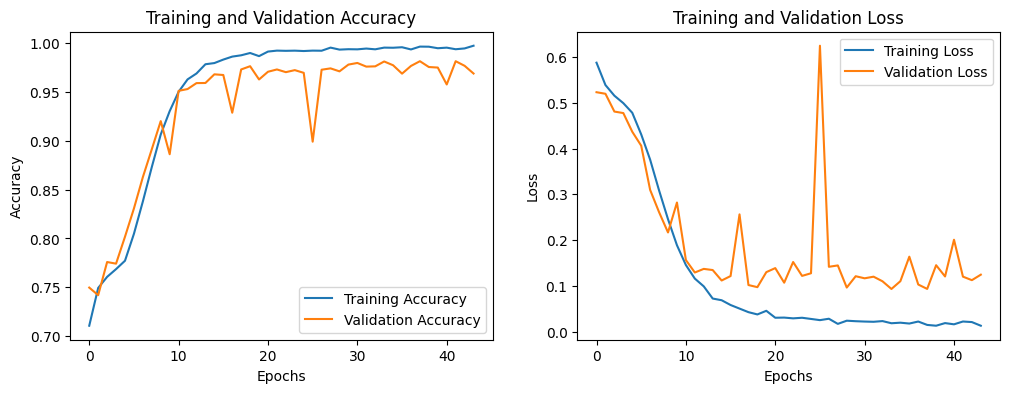

In [4]:
# Build RNN model
def build_rnn4_model(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        GRU(128, return_sequences=True, activation='tanh'),
        Dropout(0.5),
        BatchNormalization(),
        GRU(64, return_sequences=True, activation='tanh'),
        Dropout(0.5),
        BatchNormalization(),
        GRU(32, activation='tanh'),
        Dropout(0.5),
        Dense(32, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])
    return model

# Define input shape
input_shape = (X_train.shape[1], X_train.shape[2])
rnn4_model = build_rnn4_model(input_shape)

# Compile the model
rnn4_model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# **Add model summary here**
rnn4_model.summary()

# Early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = rnn4_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)

# Evaluate the model on the test set
test_loss, test_accuracy = rnn4_model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Predictions and classification report
y_pred = (rnn4_model.predict(X_test) > 0.5).astype(int).flatten()
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)

# Plot training & validation accuracy and loss
plt.figure(figsize=(12, 4))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru_9 (GRU)                 (None, 400, 128)          54912     
                                                                 
 dropout_16 (Dropout)        (None, 400, 128)          0         
                                                                 
 batch_normalization_8 (Batc  (None, 400, 128)         512       
 hNormalization)                                                 
                                                                 
 gru_10 (GRU)                (None, 400, 64)           37248     
                                                                 
 dropout_17 (Dropout)        (None, 400, 64)           0         
                                                                 
 batch_normalization_9 (Batc  (None, 400, 64)          256       
 hNormalization)                                      

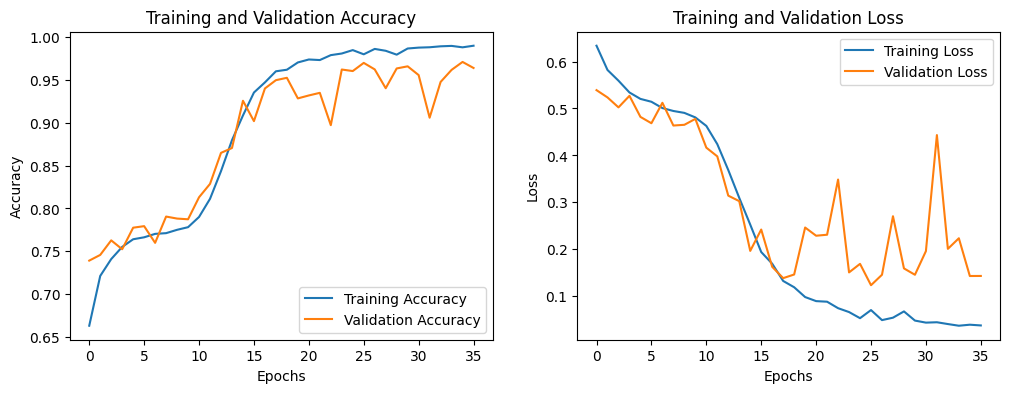

In [5]:
# Build RNN model
def build_rnn5_model(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        GRU(128, return_sequences=True, activation='tanh'),
        Dropout(0.7),
        BatchNormalization(),
        GRU(64, return_sequences=True, activation='tanh'),
        Dropout(0.7),
        BatchNormalization(),
        GRU(32, activation='tanh'),
        Dropout(0.7),
        Dense(32, activation='relu'),
        Dropout(0.7),
        Dense(1, activation='sigmoid')
    ])
    return model

# Define input shape
input_shape = (X_train.shape[1], X_train.shape[2])
rnn5_model = build_rnn5_model(input_shape)

# Compile the model
rnn5_model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# **Add model summary here**
rnn5_model.summary()

# Early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = rnn5_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)

# Evaluate the model on the test set
test_loss, test_accuracy = rnn5_model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Predictions and classification report
y_pred = (rnn5_model.predict(X_test) > 0.5).astype(int).flatten()
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)

# Plot training & validation accuracy and loss
plt.figure(figsize=(12, 4))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru_12 (GRU)                (None, 400, 128)          54912     
                                                                 
 dropout_20 (Dropout)        (None, 400, 128)          0         
                                                                 
 batch_normalization_10 (Bat  (None, 400, 128)         512       
 chNormalization)                                                
                                                                 
 gru_13 (GRU)                (None, 400, 64)           37248     
                                                                 
 dropout_21 (Dropout)        (None, 400, 64)           0         
                                                                 
 batch_normalization_11 (Bat  (None, 400, 64)          256       
 chNormalization)                                     

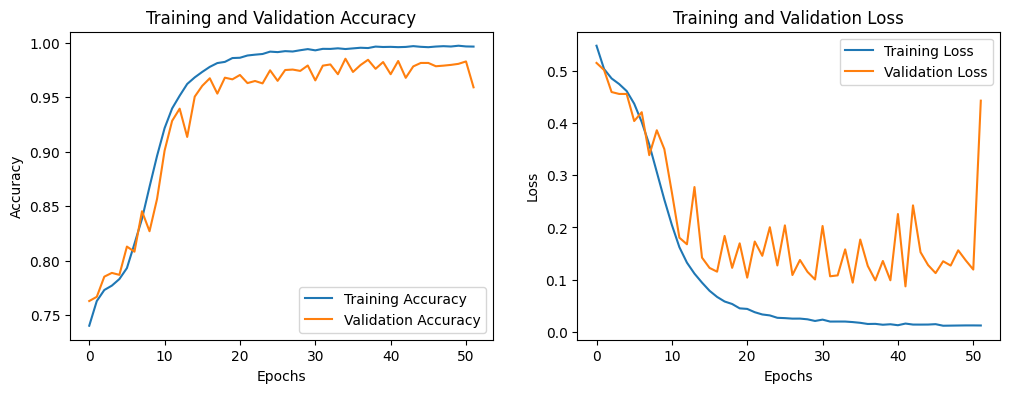

In [6]:
from tensorflow.keras.optimizers import RMSprop


# Build RNN model
def build_rnn6_model(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        GRU(128, return_sequences=True, activation='tanh'),
        Dropout(0.3),
        BatchNormalization(),
        GRU(64, return_sequences=True, activation='tanh'),
        Dropout(0.3),
        BatchNormalization(),
        GRU(32, activation='tanh'),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    return model

# Define input shape
input_shape = (X_train.shape[1], X_train.shape[2])
rnn6_model = build_rnn6_model(input_shape)

# Compile the model with RMSprop optimizer
rnn6_model.compile(optimizer=RMSprop(learning_rate=0.001), 
                   loss='binary_crossentropy', 
                   metrics=['accuracy'])

# Add model summary
rnn6_model.summary()

# Early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = rnn6_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)

# Evaluate the model on the test set
test_loss, test_accuracy = rnn6_model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Predictions and classification report
y_pred = (rnn6_model.predict(X_test) > 0.5).astype(int).flatten()
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)

# Plot training & validation accuracy and loss
plt.figure(figsize=(12, 4))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru_15 (GRU)                (None, 400, 128)          54912     
                                                                 
 dropout_24 (Dropout)        (None, 400, 128)          0         
                                                                 
 batch_normalization_12 (Bat  (None, 400, 128)         512       
 chNormalization)                                                
                                                                 
 gru_16 (GRU)                (None, 400, 64)           37248     
                                                                 
 dropout_25 (Dropout)        (None, 400, 64)           0         
                                                                 
 batch_normalization_13 (Bat  (None, 400, 64)          256       
 chNormalization)                                     

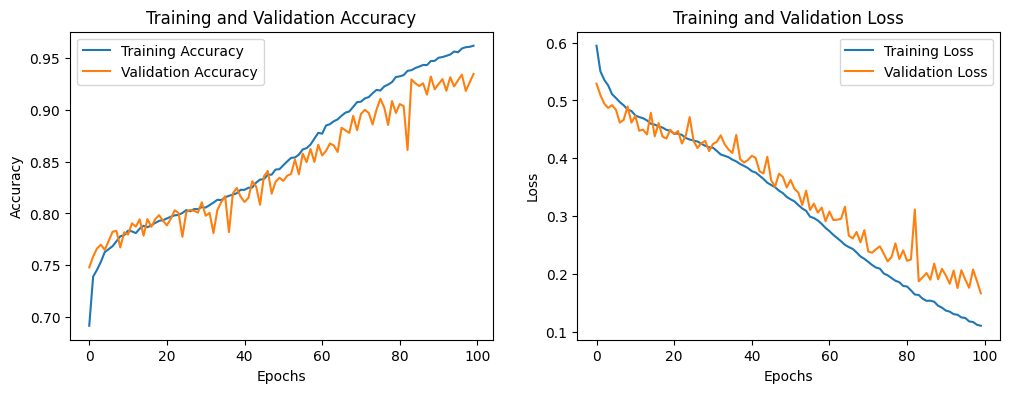

In [7]:
from tensorflow.keras.optimizers import RMSprop


# Build RNN model
def build_rnn7_model(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        GRU(128, return_sequences=True, activation='tanh'),
        Dropout(0.3),
        BatchNormalization(),
        GRU(64, return_sequences=True, activation='tanh'),
        Dropout(0.3),
        BatchNormalization(),
        GRU(32, activation='tanh'),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    return model

# Define input shape
input_shape = (X_train.shape[1], X_train.shape[2])
rnn7_model = build_rnn7_model(input_shape)

# Compile the model with RMSprop optimizer
rnn7_model.compile(optimizer=RMSprop(learning_rate=0.0001), 
                   loss='binary_crossentropy', 
                   metrics=['accuracy'])

# Add model summary
rnn7_model.summary()

# Early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = rnn7_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)

# Evaluate the model on the test set
test_loss, test_accuracy = rnn7_model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Predictions and classification report
y_pred = (rnn7_model.predict(X_test) > 0.5).astype(int).flatten()
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)

# Plot training & validation accuracy and loss
plt.figure(figsize=(12, 4))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


Model: "sequential_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_3 (LSTM)               (None, 400, 128)          72704     
                                                                 
 dropout_28 (Dropout)        (None, 400, 128)          0         
                                                                 
 batch_normalization_14 (Bat  (None, 400, 128)         512       
 chNormalization)                                                
                                                                 
 lstm_4 (LSTM)               (None, 400, 64)           49408     
                                                                 
 dropout_29 (Dropout)        (None, 400, 64)           0         
                                                                 
 batch_normalization_15 (Bat  (None, 400, 64)          256       
 chNormalization)                                     

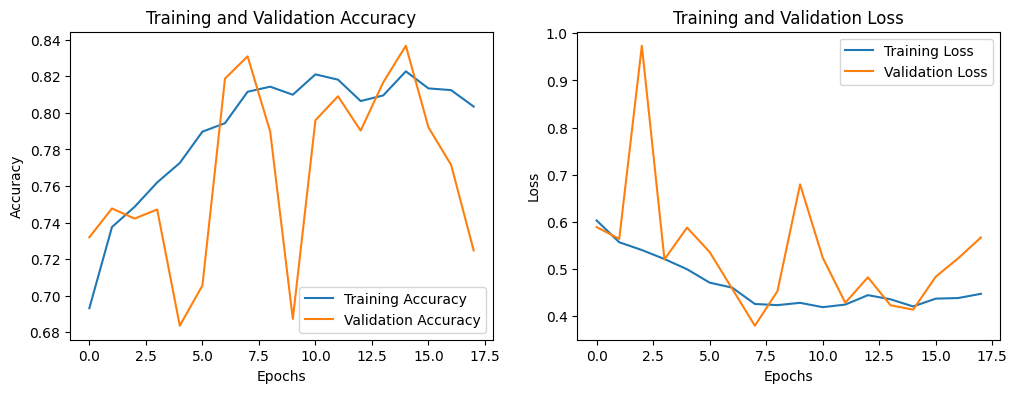

In [8]:
from tensorflow.keras.optimizers import RMSprop


# Build RNN model
def build_rnn8_model(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        LSTM(128, return_sequences=True, activation='tanh'),
        Dropout(0.3),
        BatchNormalization(),
        LSTM(64, return_sequences=True, activation='tanh'),
        Dropout(0.3),
        BatchNormalization(),
        LSTM(32, activation='tanh'),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    return model

# Define input shape
input_shape = (X_train.shape[1], X_train.shape[2])
rnn8_model = build_rnn8_model(input_shape)

# Compile the model with RMSprop optimizer
rnn8_model.compile(optimizer=RMSprop(learning_rate=0.01), 
                   loss='binary_crossentropy', 
                   metrics=['accuracy'])

# Add model summary
rnn8_model.summary()

# Early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = rnn8_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)

# Evaluate the model on the test set
test_loss, test_accuracy = rnn8_model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Predictions and classification report
y_pred = (rnn8_model.predict(X_test) > 0.5).astype(int).flatten()
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)

# Plot training & validation accuracy and loss
plt.figure(figsize=(12, 4))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


In [10]:
# Save the trained model to a file
model_save_path = "rnn6_model.keras"  # You can change the file name/path
rnn6_model.save(model_save_path)
print(f"Model saved to {model_save_path}")


Model saved to rnn6_model.keras
